# Завдання 1: Завантаження датасету та Data Cleaning

In [1]:
import pandas as pd
import numpy as np
import urllib.request
import os

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/autos/imports-85.data"
file_path = "imports-85.data"

# завантаження самого файлу
if not os.path.exists(file_path):
    print("Завантажую файл з інтернету...")
    urllib.request.urlretrieve(url, file_path)
    print("Завантажено!")

# назви колонок 
columns = ["symboling", "normalized-losses", "make", "fuel-type", "aspiration",
           "num-of-doors", "body-style", "drive-wheels", "engine-location",
           "wheel-base", "length", "width", "height", "curb-weight", "engine-type",
           "num-of-cylinders", "engine-size", "fuel-system", "bore", "stroke",
           "compression-ratio", "horsepower", "peak-rpm", "city-mpg", "highway-mpg", "price"]

print("Читаю та очищую дані...")
# зчитаю дані (пропуски позначені як '?')
df = pd.read_csv(file_path, names=columns, na_values="?")
print("Кількість рядків до очищення:", len(df))

# Data Cleaning
df_cleaned = df.dropna().copy()
df_cleaned['horsepower'] = df_cleaned['horsepower'].astype(int)
df_cleaned['price'] = df_cleaned['price'].astype(float)

print("Кількість рядків після очищення:", len(df_cleaned))
display(df_cleaned.head())

Завантажую файл з інтернету...
Завантажено!
Читаю та очищую дані...
Кількість рядків до очищення: 205
Кількість рядків після очищення: 159


,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.4,10.0,102,5500.0,24,30,13950.0
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.4,8.0,115,5500.0,18,22,17450.0
6,1,158.0,audi,gas,std,four,sedan,fwd,front,105.8,...,136,mpfi,3.19,3.4,8.5,110,5500.0,19,25,17710.0
8,1,158.0,audi,gas,turbo,four,sedan,fwd,front,105.8,...,131,mpfi,3.13,3.4,8.3,140,5500.0,17,20,23875.0
10,2,192.0,bmw,gas,std,two,sedan,rwd,front,101.2,...,108,mpfi,3.50,2.8,8.8,101,5800.0,23,29,16430.0


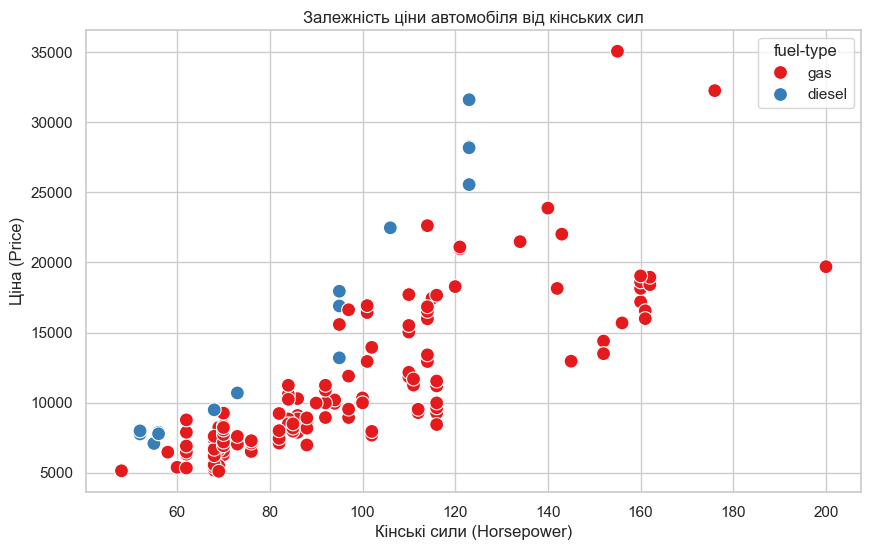

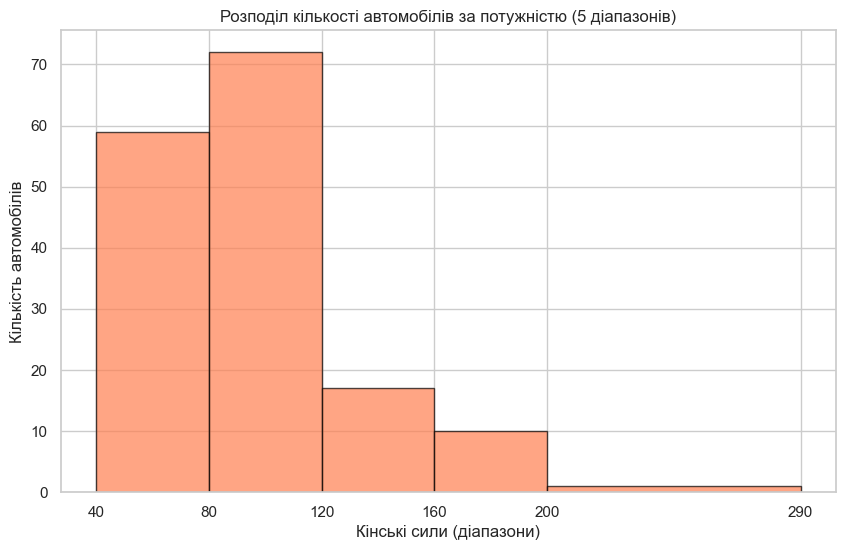

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# стиль
sns.set_theme(style="whitegrid")

# Завдання 2: Графік залежності одного атрибута від іншого
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_cleaned, x="horsepower", y="price", hue="fuel-type", s=100, palette="Set1")
plt.title("Залежність ціни автомобіля від кінських сил")
plt.xlabel("Кінські сили (Horsepower)")
plt.ylabel("Ціна")
plt.show()

# Завдання 3: Гістограма на 5 заданих діапазонів
# задаю 5 діапазонів для кінських сил
custom_bins = [40, 80, 120, 160, 200, 290]

plt.figure(figsize=(10, 6))
# гістограма
plt.hist(df_cleaned['horsepower'], bins=custom_bins, color='coral', edgecolor='black', alpha=0.7)
plt.title("Розподіл кількості автомобілів за потужністю")
plt.xlabel("Кінські сили")
plt.ylabel("Кількість автомобілів")
plt.xticks(custom_bins)
plt.show()

# Завдання 4 та 5: Багатовимірні графіки та додаткова інформація

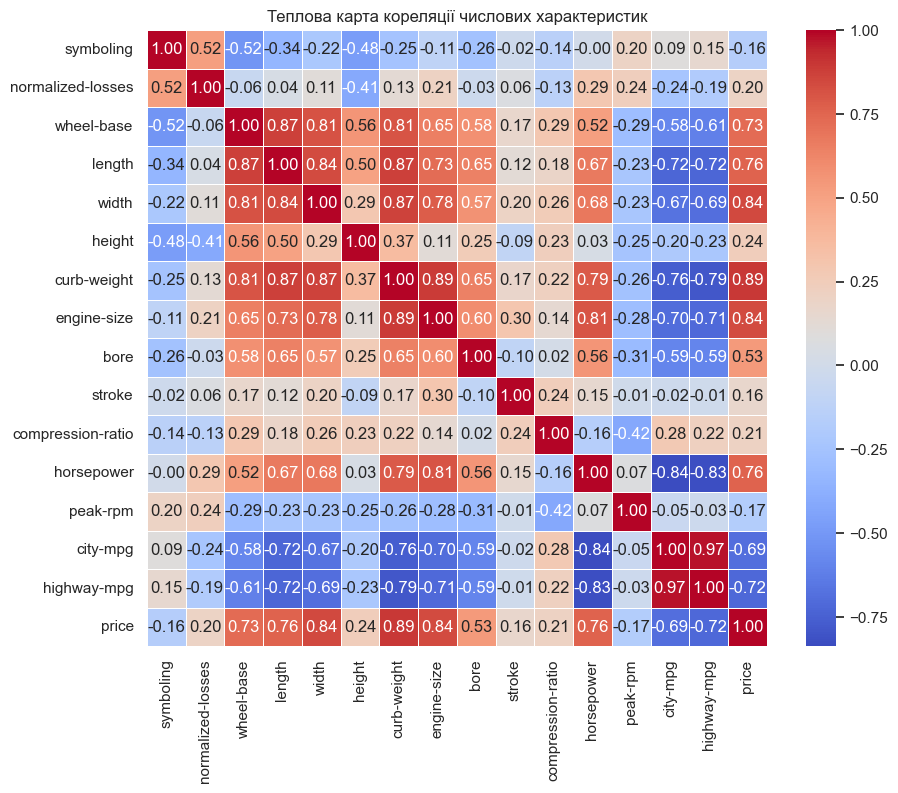

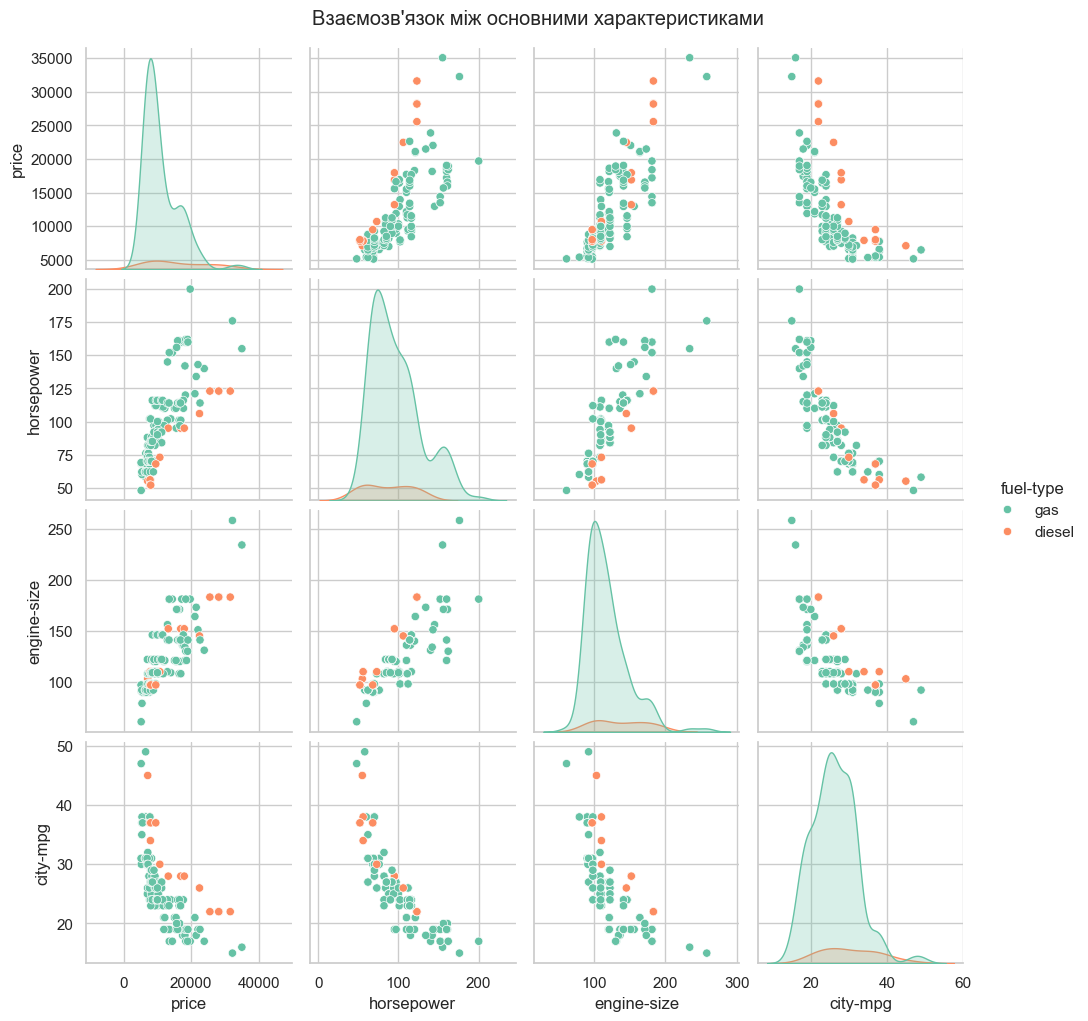

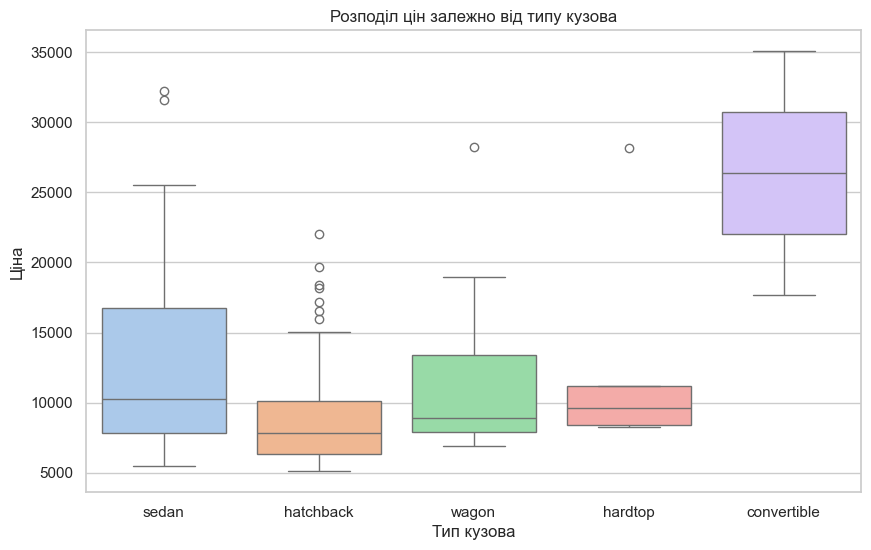

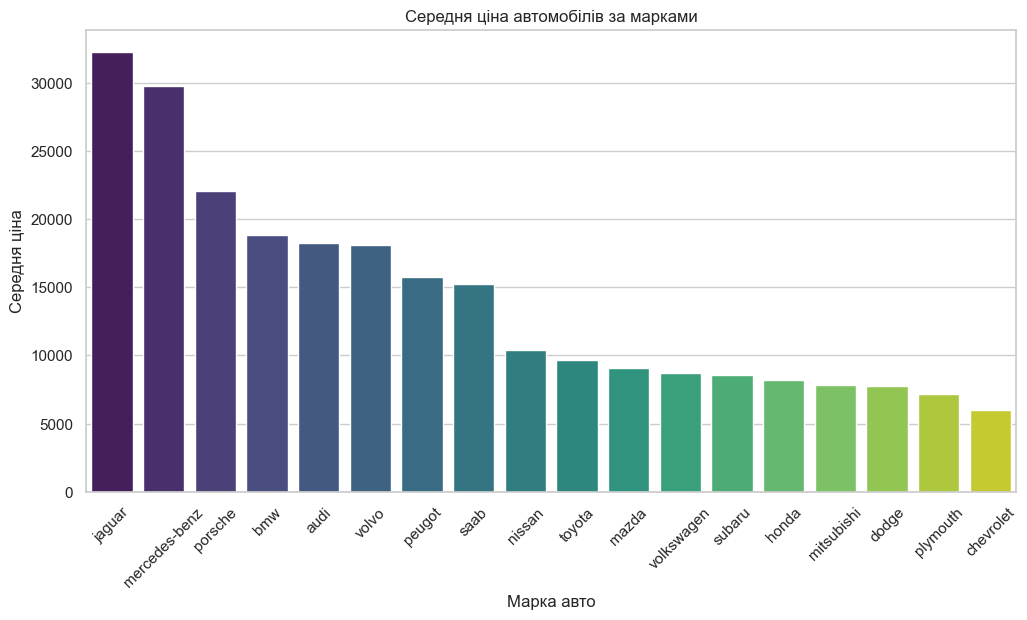

In [3]:
# 1. Heatmap
plt.figure(figsize=(10, 8))
numeric_cols = df_cleaned.select_dtypes(include=['int32', 'float64', 'int64']).columns
corr_matrix = df_cleaned[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Теплова карта кореляції числових характеристик")
plt.show()

# 2. Pairplot
cols_to_plot = ['price', 'horsepower', 'engine-size', 'city-mpg', 'fuel-type']
sns.pairplot(df_cleaned[cols_to_plot], hue="fuel-type", palette="Set2")
plt.suptitle("Взаємозв'язок між основними характеристиками", y=1.02)
plt.show()

# 3. Boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_cleaned, x="body-style", y="price", hue="body-style", palette="pastel", legend=False)
plt.title("Розподіл цін залежно від типу кузова")
plt.xlabel("Тип кузова")
plt.ylabel("Ціна")
plt.show()

# 4. Barplot
plt.figure(figsize=(12, 6))
price_by_make = df_cleaned.groupby('make')['price'].mean().sort_values(ascending=False)
sns.barplot(x=price_by_make.index, y=price_by_make.values, hue=price_by_make.index, palette="viridis", legend=False)
plt.title("Середня ціна автомобілів за марками")
plt.xlabel("Марка авто")
plt.ylabel("Середня ціна")
plt.xticks(rotation=45)
plt.show()